In [1]:
# ============================================================
# CELL 0: GPU SETUP & VERIFICATION
# ============================================================
!pip install scanpy anndata matplotlib seaborn scipy -q

import subprocess
import sys

print("=" * 70)
print("  V18 C3: GPU ENVIRONMENT SETUP")
print("=" * 70)

# GPU detection
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,compute_cap',
                            '--format=csv,noheader'], capture_output=True, text=True)
    gpu_info = result.stdout.strip()
    print(f"✅ GPU detected: {gpu_info}")
except:
    print("⚠️ No GPU detected — will use CPU fallback")

# Install CuPy for GPU acceleration
try:
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} ready")
    print(f"   GPU memory: {cp.cuda.Device(0).mem_info[1] / 1e9:.1f} GB total")
except ImportError:
    print("📦 Installing CuPy...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'cupy-cuda12x', '-q'])
    import cupy as cp
    print(f"✅ CuPy {cp.__version__} installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.1 MB/s eta 0:00:00
  V18 C3: GPU ENVIRONMENT SETUP
✅ GPU detected: NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0
✅ CuPy 14.0.1 ready
   GPU memory: 85.1 GB total


In [2]:
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# ========================================
# Figure 3: Pan-Tissue IT-Specific Gene Signatures
# Panel A: HLA-DPB1 (Myeloid)
# Panel B: DNMT1 (Myeloid)
# Panel C: JAK1 (cross-lineage)
# Panel D: PRDM1 (CD4T + CD8T)
# ========================================
print("\n" + "=" * 70)
print("  CELL 1: DATA LOADING")
print("=" * 70)

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import mannwhitneyu
import os
import time
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
OUTPUT_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/Figure3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

t0 = time.time()
adata = sc.read_h5ad(DATA_PATH)
print(f"✅ Loaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes in {time.time()-t0:.1f}s")

GROUPS = ['NL', 'IT', 'IA', 'AR', 'CR']

# Ensure donor_id exists
if 'donor_id' not in adata.obs.columns:
    adata.obs['donor_id'] = adata.obs['sample'].str.split('_').str[1]

col_donor = 'donor_id'
col_tissue = 'tissue'
col_stage = 'Stage'
col_lineage = 'major_lineage'

tissue_vals = adata.obs[col_tissue].unique()
liver_name = [t for t in tissue_vals if 'liver' in str(t).lower()][0]
blood_name = [t for t in tissue_vals if 'blood' in str(t).lower()][0]

def get_donor_expression(adata, gene, lineage, tissue_label):
    """Extract donor-level mean expression for a gene in a lineage/tissue."""
    mask = ((adata.obs[col_lineage] == lineage) &
            (adata.obs[col_tissue] == tissue_label))
    sub = adata[mask]

    if gene not in sub.var_names:
        print(f"  ⚠️ {gene} not found in var_names!")
        return pd.DataFrame()

    # Extract expression
    if hasattr(sub.X, 'toarray'):
        expr = sub[:, gene].X.toarray().flatten()
    else:
        expr = sub[:, gene].X.flatten()

    df = pd.DataFrame({
        'donor': sub.obs[col_donor].values,
        'stage': sub.obs[col_stage].values,
        'expression': expr
    })

    # Donor-level mean
    donor_means = df.groupby(['donor', 'stage'])['expression'].mean().reset_index()
    return donor_means

def plot_gene_dotplot(ax, gene, lineage, title, show_legend=True):
    """Plot donor-level dot plot: Liver=red circle, Blood=blue triangle."""
    np.random.seed(42)
    jitter = 0.12

    liver_data = get_donor_expression(adata, gene, lineage, liver_name)
    blood_data = get_donor_expression(adata, gene, lineage, blood_name)

    # Compute p-values vs NL
    pvals = {'Liver': {}, 'Blood': {}}
    for g in GROUPS[1:]:
        for tissue_name, data in [('Liver', liver_data), ('Blood', blood_data)]:
            nl_vals = data[data['stage'] == 'NL']['expression'].values
            g_vals = data[data['stage'] == g]['expression'].values
            if len(nl_vals) >= 2 and len(g_vals) >= 2:
                _, p = mannwhitneyu(nl_vals, g_vals, alternative='two-sided')
                pvals[tissue_name][g] = p
            else:
                pvals[tissue_name][g] = None

    # Plot
    for i, g in enumerate(GROUPS):
        # Liver
        lv = liver_data[liver_data['stage'] == g]['expression'].values
        if len(lv) > 0:
            xj = np.random.uniform(-jitter, jitter, len(lv)) + i - 0.15
            ax.scatter(xj, lv, c='#E64B35', marker='o', s=30, alpha=0.7,
                      edgecolors='#B83224', linewidth=0.5, zorder=3)
            ax.plot([i-0.28, i-0.02], [np.mean(lv)]*2, c='#E64B35', lw=2, zorder=4)

        # Blood
        bv = blood_data[blood_data['stage'] == g]['expression'].values
        if len(bv) > 0:
            xj = np.random.uniform(-jitter, jitter, len(bv)) + i + 0.15
            ax.scatter(xj, bv, c='#3C5488', marker='^', s=30, alpha=0.7,
                      edgecolors='#2A3D66', linewidth=0.5, zorder=3)
            ax.plot([i+0.02, i+0.28], [np.mean(bv)]*2, c='#3C5488', lw=2, zorder=4)

    # Add NL→IT p-values
    for tissue_name, color, x_offset in [('Liver', '#E64B35', -0.15), ('Blood', '#3C5488', 0.15)]:
        p = pvals[tissue_name].get('IT')
        data_for = liver_data if tissue_name == 'Liver' else blood_data
        if p is not None and p < 0.05:
            it_vals = data_for[data_for['stage'] == 'IT']['expression'].values
            y_pos = max(it_vals) if len(it_vals) > 0 else 0
            ax.annotate(f'★p={p:.3f}', xy=(1 + x_offset, y_pos),
                       xytext=(1 + x_offset, y_pos + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.08),
                       fontsize=5.5, ha='center', color=color, fontweight='bold',
                       arrowprops=dict(arrowstyle='-', color=color, lw=0.4))

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('Expression (log-normalized)', fontsize=7)

    if show_legend:
        liver_h = plt.scatter([], [], c='#E64B35', marker='o', s=25, label='Liver')
        blood_h = plt.scatter([], [], c='#3C5488', marker='^', s=25, label='Blood')
        ax.legend(handles=[liver_h, blood_h], loc='upper right', fontsize=6, frameon=True)

    return pvals

# Verify genes exist
for gene in ['HLA-DPB1', 'DNMT1', 'JAK1', 'PRDM1']:
    found = gene in adata.var_names
    print(f"  {gene}: {'✅ found' if found else '❌ NOT FOUND'}")


  CELL 1: DATA LOADING
✅ Loaded: 243,000 cells × 24,452 genes in 22.6s
  HLA-DPB1: ✅ found
  DNMT1: ✅ found
  JAK1: ✅ found
  PRDM1: ✅ found


In [9]:
# ========================================
# DIAGNOSTIC: Why are p-values NaN?
# ========================================

# Test with HLA-DPB1 Myeloid
test = get_donor_expression(adata, 'HLA-DPB1', 'Myeloid', liver_name)
print(f"Returned rows: {len(test)}")
print(f"Columns: {list(test.columns)}")
print(f"Stage dtype: {test['stage'].dtype}")
print(f"Stage unique: {test['stage'].unique()}")
print(f"\nFiltering test:")
for g in GROUPS:
    subset = test[test['stage'] == g]
    print(f"  stage=='{g}': {len(subset)} rows, values={subset['expression'].values[:3]}")

# Check if it's a categorical issue
print(f"\nadata Stage dtype: {adata.obs[col_stage].dtype}")
print(f"adata Stage categories: {adata.obs[col_stage].cat.categories if hasattr(adata.obs[col_stage], 'cat') else 'not categorical'}")

Returned rows: 115
Columns: ['donor', 'stage', 'expression']
Stage dtype: category
Stage unique: ['CR', 'AR', 'IA', 'IT', 'NL']
Categories (5, object): ['CR', 'AR', 'IA', 'IT', 'NL']

Filtering test:
  stage=='NL': 23 rows, values=[2.0408475 1.6917729 2.6786528]
  stage=='IT': 23 rows, values=[nan nan nan]
  stage=='IA': 23 rows, values=[nan nan nan]
  stage=='AR': 23 rows, values=[nan nan nan]
  stage=='CR': 23 rows, values=[nan nan nan]

adata Stage dtype: category
adata Stage categories: Index(['CR', 'AR', 'IA', 'IT', 'NL'], dtype='object')


In [13]:
# ========================================
# FIX: get_donor_expression — categorical 문제 해결
# ========================================
def get_donor_expression(adata, gene, lineage, tissue_label):
    """Extract donor-level mean expression for a gene in a lineage/tissue."""
    mask = ((adata.obs[col_lineage] == lineage) &
            (adata.obs[col_tissue] == tissue_label))
    sub = adata[mask]

    if gene not in sub.var_names:
        print(f"  ⚠️ {gene} not found!")
        return pd.DataFrame()

    if hasattr(sub.X, 'toarray'):
        expr = sub[:, gene].X.toarray().flatten()
    else:
        expr = sub[:, gene].X.flatten()

    df = pd.DataFrame({
        'donor': sub.obs[col_donor].values,
        'stage': sub.obs[col_stage].astype(str).values,  # ← FIX: convert to string
        'expression': expr
    })

    donor_means = df.groupby(['donor', 'stage'], observed=True)['expression'].mean().reset_index()
    return donor_means

# Verify fix
test = get_donor_expression(adata, 'HLA-DPB1', 'Myeloid', liver_name)
print(f"Total rows: {len(test)}")
for g in GROUPS:
    subset = test[test['stage'] == g]
    vals = subset['expression'].values
    print(f"  {g}: n={len(subset)}, mean={np.mean(vals):.4f}, NaN count={np.isnan(vals).sum()}")

Total rows: 23
  NL: n=6, mean=1.9150, NaN count=0
  IT: n=6, mean=3.7300, NaN count=0
  IA: n=5, mean=3.0634, NaN count=0
  AR: n=3, mean=3.6865, NaN count=0
  CR: n=3, mean=3.2472, NaN count=0


Panel A: HLA-DPB1 / Myeloid
Panel B: DNMT1 / Myeloid
Panel C: JAK1 / multi-lineage
Panel D: PRDM1 / CD4_T + CD8_T
  PRDM1 Liver CD4_T: NL→IT p=0.0022 ★
  PRDM1 Blood CD4_T: NL→IT p=0.0079 ★
  PRDM1 Blood CD8_T: NL→IT p=0.0079 ★


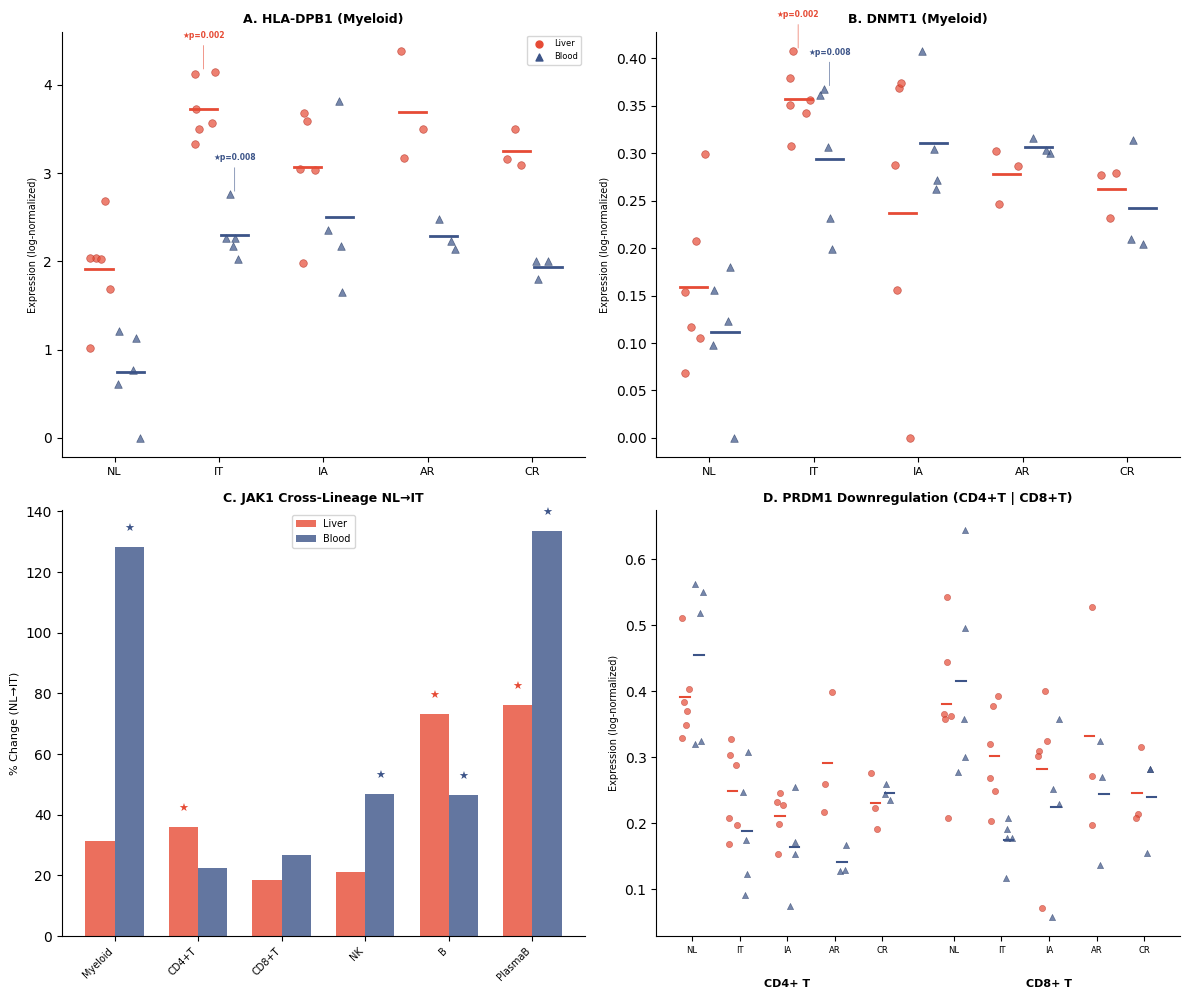


✅ Saved Figure3 to /content/drive/MyDrive/ITLAS/results/version18-analysis/Figure3


In [14]:
# ========================================
# Figure 3 Panels A & B: HLA-DPB1 and DNMT1 (Myeloid)
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: HLA-DPB1 Myeloid
print("Panel A: HLA-DPB1 / Myeloid")
pv_a = plot_gene_dotplot(axes[0,0], 'HLA-DPB1', 'Myeloid',
                          'A. HLA-DPB1 (Myeloid)', show_legend=True)

# Panel B: DNMT1 Myeloid
print("Panel B: DNMT1 / Myeloid")
pv_b = plot_gene_dotplot(axes[0,1], 'DNMT1', 'Myeloid',
                          'B. DNMT1 (Myeloid)', show_legend=False)

# Panel C: JAK1 — show multiple lineages in one panel
print("Panel C: JAK1 / multi-lineage")
ax_c = axes[1,0]
lineages_for_jak1 = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB']
jak1_liver_means = []
jak1_blood_means = []
jak1_liver_pvals = []
jak1_blood_pvals = []

for lin in lineages_for_jak1:
    ld = get_donor_expression(adata, 'JAK1', lin, liver_name)
    bd = get_donor_expression(adata, 'JAK1', lin, blood_name)

    nl_l = ld[ld['stage']=='NL']['expression'].values
    it_l = ld[ld['stage']=='IT']['expression'].values
    nl_b = bd[bd['stage']=='NL']['expression'].values
    it_b = bd[bd['stage']=='IT']['expression'].values

    l_mean_nl = np.mean(nl_l) if len(nl_l)>0 else 0
    l_mean_it = np.mean(it_l) if len(it_l)>0 else 0
    b_mean_nl = np.mean(nl_b) if len(nl_b)>0 else 0
    b_mean_it = np.mean(it_b) if len(it_b)>0 else 0

    l_pct = ((l_mean_it - l_mean_nl)/l_mean_nl*100) if l_mean_nl > 0.001 else 0
    b_pct = ((b_mean_it - b_mean_nl)/b_mean_nl*100) if b_mean_nl > 0.001 else 0

    jak1_liver_means.append(l_pct)
    jak1_blood_means.append(b_pct)

    # p-values
    if len(nl_l)>=2 and len(it_l)>=2:
        _, lp = mannwhitneyu(nl_l, it_l, alternative='two-sided')
    else: lp = None
    if len(nl_b)>=2 and len(it_b)>=2:
        _, bp = mannwhitneyu(nl_b, it_b, alternative='two-sided')
    else: bp = None
    jak1_liver_pvals.append(lp)
    jak1_blood_pvals.append(bp)

x = np.arange(len(lineages_for_jak1))
width = 0.35
bars_l = ax_c.bar(x - width/2, jak1_liver_means, width, color='#E64B35', alpha=0.8, label='Liver')
bars_b = ax_c.bar(x + width/2, jak1_blood_means, width, color='#3C5488', alpha=0.8, label='Blood')

# Add significance stars
for i in range(len(lineages_for_jak1)):
    lp = jak1_liver_pvals[i]
    bp = jak1_blood_pvals[i]
    if lp is not None and lp < 0.05:
        y = max(jak1_liver_means[i], 0) + 5
        ax_c.text(i - width/2, y, '★', fontsize=8, ha='center', color='#E64B35', fontweight='bold')
    if bp is not None and bp < 0.05:
        y = max(jak1_blood_means[i], 0) + 5
        ax_c.text(i + width/2, y, '★', fontsize=8, ha='center', color='#3C5488', fontweight='bold')

ax_c.set_xticks(x)
ax_c.set_xticklabels(['Myeloid','CD4+T','CD8+T','NK','B','PlasmaB'], fontsize=7, rotation=45, ha='right')
ax_c.set_ylabel('% Change (NL→IT)', fontsize=8)
ax_c.set_title('C. JAK1 Cross-Lineage NL→IT', fontsize=9, fontweight='bold')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax_c.legend(fontsize=7)

# Panel D: PRDM1 CD4_T and CD8_T
print("Panel D: PRDM1 / CD4_T + CD8_T")
ax_d = axes[1,1]
# Two sub-panels in one: CD4_T (left half) and CD8_T (right half)
lineages_prdm1 = ['CD4_T', 'CD8_T']
prdm1_data = {}

for lin in lineages_prdm1:
    for tissue_label, tissue_name in [(liver_name, 'Liver'), (blood_name, 'Blood')]:
        dd = get_donor_expression(adata, 'PRDM1', lin, tissue_label)
        for g in GROUPS:
            vals = dd[dd['stage']==g]['expression'].values
            prdm1_data[(lin, tissue_name, g)] = vals

# Plot as grouped dot plot: 10 positions (5 groups × 2 lineages)
np.random.seed(42)
positions = []
labels = []
pos = 0
for lin_label, lin in [('CD4+T', 'CD4_T'), ('CD8+T', 'CD8_T')]:
    for g in GROUPS:
        # Liver
        lv = prdm1_data.get((lin, 'Liver', g), [])
        bv = prdm1_data.get((lin, 'Blood', g), [])

        if len(lv) > 0:
            xj = np.random.uniform(-0.1, 0.1, len(lv)) + pos - 0.15
            ax_d.scatter(xj, lv, c='#E64B35', marker='o', s=20, alpha=0.7,
                        edgecolors='#B83224', linewidth=0.4, zorder=3)
            ax_d.plot([pos-0.25, pos-0.05], [np.mean(lv)]*2, c='#E64B35', lw=1.5, zorder=4)
        if len(bv) > 0:
            xj = np.random.uniform(-0.1, 0.1, len(bv)) + pos + 0.15
            ax_d.scatter(xj, bv, c='#3C5488', marker='^', s=20, alpha=0.7,
                        edgecolors='#2A3D66', linewidth=0.4, zorder=3)
            ax_d.plot([pos+0.05, pos+0.25], [np.mean(bv)]*2, c='#3C5488', lw=1.5, zorder=4)

        positions.append(pos)
        labels.append(g)
        pos += 1
    pos += 0.5  # gap between lineages

ax_d.set_xticks(positions)
ax_d.set_xticklabels(labels, fontsize=6)
ax_d.set_ylabel('Expression (log-normalized)', fontsize=7)
ax_d.set_title('D. PRDM1 Downregulation (CD4+T | CD8+T)', fontsize=9, fontweight='bold')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# Add lineage labels
mid_cd4 = np.mean(positions[:5])
mid_cd8 = np.mean(positions[5:])
ax_d.text(mid_cd4, ax_d.get_ylim()[0] - (ax_d.get_ylim()[1]-ax_d.get_ylim()[0])*0.12,
          'CD4+ T', ha='center', fontsize=8, fontweight='bold')
ax_d.text(mid_cd8, ax_d.get_ylim()[0] - (ax_d.get_ylim()[1]-ax_d.get_ylim()[0])*0.12,
          'CD8+ T', ha='center', fontsize=8, fontweight='bold')

# Add NL→IT p-values for PRDM1
for lin in ['CD4_T', 'CD8_T']:
    for tissue_label, tissue_name in [(liver_name, 'Liver'), (blood_name, 'Blood')]:
        nl = prdm1_data.get((lin, tissue_name, 'NL'), [])
        it = prdm1_data.get((lin, tissue_name, 'IT'), [])
        if len(nl) >= 2 and len(it) >= 2:
            _, p = mannwhitneyu(nl, it, alternative='two-sided')
            if p < 0.05:
                print(f"  PRDM1 {tissue_name} {lin}: NL→IT p={p:.4f} ★")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure3_pan_tissue_signatures.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(OUTPUT_DIR, 'Figure3_pan_tissue_signatures.pdf'), bbox_inches='tight')
plt.show()
print(f'\n✅ Saved Figure3 to {OUTPUT_DIR}')

In [15]:
# ========================================
# Figure 3: Print all p-values for verification
# ========================================
print("="*70)
print("FIGURE 3 P-VALUE SUMMARY")
print("="*70)

print("\nA. HLA-DPB1 Myeloid NL→IT:")
for t in ['Liver', 'Blood']:
    p = pv_a[t].get('IT')
    print(f"  {t}: p={p:.4f}" + (" ★" if p and p<0.05 else ""))

print("\nB. DNMT1 Myeloid NL→IT:")
for t in ['Liver', 'Blood']:
    p = pv_b[t].get('IT')
    print(f"  {t}: p={p:.4f}" + (" ★" if p and p<0.05 else ""))

print("\nC. JAK1 Cross-lineage NL→IT:")
for i, lin in enumerate(lineages_for_jak1):
    lp = jak1_liver_pvals[i]
    bp = jak1_blood_pvals[i]
    lp_str = f"p={lp:.4f}" if lp else "NA"
    bp_str = f"p={bp:.4f}" if bp else "NA"
    l_sig = " ★" if lp and lp < 0.05 else ""
    b_sig = " ★" if bp and bp < 0.05 else ""
    print(f"  {lin:<10} Liver: {lp_str}{l_sig:>3}  Blood: {bp_str}{b_sig:>3}  "
          f"L={jak1_liver_means[i]:+.1f}%  B={jak1_blood_means[i]:+.1f}%")

print("\nD. PRDM1 NL→IT:")
for lin in ['CD4_T', 'CD8_T']:
    for tissue_label, tissue_name in [(liver_name, 'Liver'), (blood_name, 'Blood')]:
        nl = prdm1_data.get((lin, tissue_name, 'NL'), [])
        it = prdm1_data.get((lin, tissue_name, 'IT'), [])
        if len(nl) >= 2 and len(it) >= 2:
            _, p = mannwhitneyu(nl, it, alternative='two-sided')
            nl_m = np.mean(nl)
            it_m = np.mean(it)
            pct = (it_m - nl_m)/nl_m*100 if nl_m > 0.001 else 0
            sig = " ★" if p < 0.05 else ""
            print(f"  {tissue_name:<6} {lin:<6}: {pct:+.1f}% p={p:.4f}{sig}")

print("\n" + "="*70)
print("VERIFICATION vs Results 2.2:")
print("  HLA-DPB1 Liver Myeloid: expect ★↑94.8% p=0.002")
print("  DNMT1 Liver Myeloid: expect ★↑125.2% p=0.002")
print("  JAK1 B Liver: expect ★↑73.1% p=0.004")
print("  PRDM1 CD4_T Liver: expect ★↓36.4% p=0.002 (36/36)")
print("="*70)

FIGURE 3 P-VALUE SUMMARY

A. HLA-DPB1 Myeloid NL→IT:
  Liver: p=0.0022 ★
  Blood: p=0.0079 ★

B. DNMT1 Myeloid NL→IT:
  Liver: p=0.0022 ★
  Blood: p=0.0079 ★

C. JAK1 Cross-lineage NL→IT:
  Myeloid    Liver: p=0.1320     Blood: p=0.0079  ★  L=+31.2%  B=+128.3%
  CD4_T      Liver: p=0.0411  ★  Blood: p=0.0952     L=+36.0%  B=+22.3%
  CD8_T      Liver: p=0.1320     Blood: p=0.5476     L=+18.4%  B=+26.8%
  NK         Liver: p=0.3095     Blood: p=0.0079  ★  L=+21.0%  B=+46.9%
  B          Liver: p=0.0043  ★  Blood: p=0.0079  ★  L=+73.1%  B=+46.6%
  PlasmaB    Liver: p=0.0173  ★  Blood: p=0.0159  ★  L=+76.1%  B=+133.7%

D. PRDM1 NL→IT:
  Liver  CD4_T : -36.4% p=0.0022 ★
  Blood  CD4_T : -58.5% p=0.0079 ★
  Liver  CD8_T : -20.5% p=0.3095
  Blood  CD8_T : -57.9% p=0.0079 ★

VERIFICATION vs Results 2.2:
  HLA-DPB1 Liver Myeloid: expect ★↑94.8% p=0.002
  DNMT1 Liver Myeloid: expect ★↑125.2% p=0.002
  JAK1 B Liver: expect ★↑73.1% p=0.004
  PRDM1 CD4_T Liver: expect ★↓36.4% p=0.002 (36/36)
